In [187]:
import warnings 
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from glob import glob 
from itertools import combinations
from networkx.drawing.nx_agraph import graphviz_layout

from utils import load_hframe

warnings.filterwarnings('ignore')
%matplotlib inline
%load_ext autoreload
%autoreload 2

pd.options.display.float_format = "{:,.3f}".format
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)

INDIR_DPCLUST = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/26.03.2026/ccf/Clonal_trees'
INDIR_CONIPHER = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/06.03.2026/conipher_trees'

INFILE_MUTATIONS = '/home/grace/work/PPCG_DifferentialGenesetMutation/outputs/alldonors_01042026/variant_processing/mutations.filtered.tsv'
INFILE_CLONE_META = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/angel/26.03.2026/metastatic_clones_with_ancestors.tsv'
INFILE_SHEET = '/home/grace/work/PPCG_DifferentialGenesetMutation/samplesheet.angel.alldonors.tsv'
OUTFILE_MASTER = '/home/grace/work/PPCG_DifferentialGenesetMutation/data/manual/mutations.assigned.010426.tsv'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [214]:
df = pd.read_csv('/home/grace/work/PPCG_DifferentialGenesetMutation/test/all.mutations.assigned.tsv', sep='\t', header=0)
print(df['method'].value_counts(dropna=False))
df[df['clone'].notna()].head()

method
NaN                         173462
site-parsimony (exact)       42758
DPC direct                   21834
site-parsimony (inexact)      2268
Name: count, dtype: int64


,sample,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,clone,method
14904,PPCG0086a,13:95377101-13:95745320,.,.,SV,DUP,transcript_ablation,NaN,ABCC4,4.000,site-parsimony (exact)
14905,PPCG0086a,chr10:27035522-27150016,.,1+0,CNA,CNA,LOH,0.990,ABI1,1.000,site-parsimony (exact)
14906,PPCG0086a,3:131842350-3:132284558,.,.,SV,DUP,transcript_ablation,NaN,ACAD11,5.000,site-parsimony (exact)
14907,PPCG0086a,19:5939647-19:6165257,.,.,SV,DUP,bidirectional_gene_fusion,NaN,ACSBG2,1.000,site-parsimony (exact)
14908,PPCG0086a,1:18136004-6:45820352,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1.000,site-parsimony (exact)


In [188]:
def load_mutations(mutations_path: str, samplesheet_path: str) -> pd.DataFrame:
    df = pd.read_csv(mutations_path, sep='\t', header=0)
    sheet = pd.read_csv(samplesheet_path, sep='\t', header=0)
    sheet['tissue'] = sheet['tissue'].replace('Recurrence', 'Metastasis')
    donor2cohort = sheet.drop_duplicates('donor').set_index('donor')['cohort'].to_dict()
    sample2tissue = sheet.drop_duplicates('sample').set_index('sample')['tissue'].to_dict()
    df['cohort'] = df['donor'].map(donor2cohort)
    df['tissue'] = df['sample'].map(sample2tissue)
    assert df['cohort'].isna().sum() == 0
    assert df['tissue'].isna().sum() == 0
    return df 

muts = load_mutations(INFILE_MUTATIONS, INFILE_SHEET)
muts.head()

,sample,donor,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,cohort,tissue
0,PPCG0322a,PPCG0322,3:132062590-21:42839615,.,.,SV,TRA,gene_fusion,NaN,ACP3,PPCG,Primary
1,PPCG0322a,PPCG0322,3:132062590-21:42839615,.,.,SV,TRA,gene_fusion,NaN,TMPRSS2,PPCG,Primary
2,PPCG0322a,PPCG0322,4:153179188-5:71525815,.,.,SV,TRA,transcript_ablation,NaN,MRPS27,PPCG,Primary
3,PPCG0322a,PPCG0322,9:9618517-9:9619627,.,.,SV,INV,bidirectional_gene_fusion,NaN,PTPRD,PPCG,Primary
4,PPCG0322a,PPCG0322,9:9474532-9:9619633,.,.,SV,INV,bidirectional_gene_fusion,NaN,PTPRD,PPCG,Primary


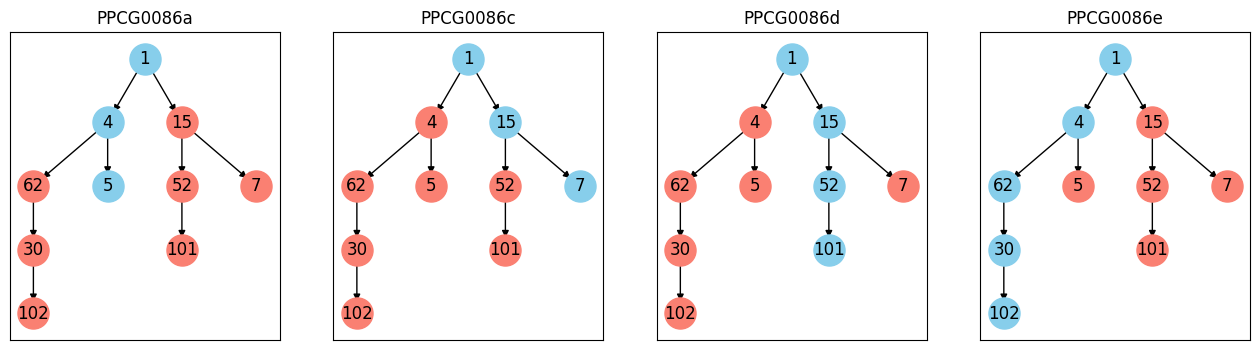

         PPCG0086a  PPCG0086c  PPCG0086d  PPCG0086e
Cluster                                            
1            0.990      1.000      1.000      1.000
4            0.970      0.000      0.000      1.000
5            0.960      0.000      0.000      0.000
7            0.000      0.330      0.000      0.000
101          0.000      0.000      0.280      0.000
102          0.000      0.000      0.000      0.110
15           0.000      0.970      1.000      0.000
30           0.000      0.000      0.000      0.350
52           0.000      0.000      0.950      0.000
62           0.000      0.000      0.000      0.850
winner=1, score=0.01, method=site-parsimony (exact), obs={'PPCG0086a': 1.0, 'PPCG0086c': 1.0, 'PPCG0086d': 1.0, 'PPCG0086e': 1.0}
winner=4, score=0.03, method=site-parsimony (exact), obs={'PPCG0086a': 1.0, 'PPCG0086e': 1.0}
winner=15, score=0.03, method=site-parsimony (exact), obs={'PPCG0086c': 1.0, 'PPCG0086d': 1.0}
winner=1, score=2.01, method=site-parsimony (inexact), ob

In [189]:
class SiteParsimonyAssigner:
    
    def __init__(self, ccfs_path: str, tree_path: str) -> None:
        self.ccfs = self._load_dpclust_ccfs(ccfs_path)
        self.tree = self._load_conipher_tree(tree_path)
        self._sampat2clones_LUT = self._generate_sampat2clones_LUT()
        self._clone2ccfs_LUT = self._generate_clone2ccfs_LUT()

        # print('\n_sampat2clones_LUT')
        # for k, v in self._sampat2clones_LUT.items():
        #     print(k, v)
        # print('\n_clone2ccfs_LUT')
        # for k, v in self._clone2ccfs_LUT.items():
        #     print(k, v)
    
    def assign(self, obs_samples2ccfs: dict[str, float]) -> tuple[str, float, bool]:
        assert len(obs_samples2ccfs) > 0
        obs_sams = sorted(list(obs_samples2ccfs.keys()))
        candidates = self._sampat2clones_LUT[tuple(obs_sams)]

        if len(candidates) == 0:
            raise RuntimeError
        
        scores = []
        for clone in candidates:
            dpc_samples2ccfs = self._clone2ccfs_LUT[clone]
            assert len(set(obs_samples2ccfs.keys()) - set(dpc_samples2ccfs.keys())) == 0
            score = 0
            exact = True
            for sample in dpc_samples2ccfs.keys():
                if sample not in obs_samples2ccfs:
                    score += 1 # penalty for variant not being witnessed in a sample it should 
                    exact = False
                    continue
                score += abs(dpc_samples2ccfs[sample] - obs_samples2ccfs[sample])
            scores.append((clone, score, exact))
        
        scores = sorted(scores, key=lambda x: x[1])
        return scores[0]
    
    def _load_dpclust_ccfs(self, filepath: str, minccf: float=0.05) -> pd.DataFrame:
        df = pd.read_csv(filepath, sep=',', header=0)
        df['Cluster'] = df['Cluster'].apply(lambda x: str(x).replace('_', '').split('.')[0])
        df = df.set_index('Cluster')
        df.columns = [x.replace('_DNA', '') for x in df.columns]
        df = df[[x for x in df.columns if x.startswith('PPCG')]].copy()
        for col in df.columns:
            mask = df[col]<minccf
            df.loc[mask, col] = 0.00
        df = df.clip(lower=0, upper=1)
        return df.copy()
    
    def _load_conipher_tree(self, filepath: str) -> nx.DiGraph:
        patient = self.ccfs.columns.to_list()[0][:8]
        T = self._load_tree1(filepath)
        
        # hacky hot-fix for PPCG0435 where clone 11 was merged into clone 4 (trunk)
        if patient == 'PPCG0435':
            T.remove_node('11')
            
        T = self._annotate_samples(T)
        return T

    def _annotate_samples(self, T: nx.DiGraph) -> nx.DiGraph:
        df = self.ccfs.T.copy()
        for node in T.nodes():
            present = df[df[node]>0].index.to_list()
            T.nodes[node]['samples'] = set(present)
        return T

    def _load_tree1(self, filepath: str) -> nx.DiGraph:

        trees = {}
        
        with open(filepath, 'r') as fp:
            line = fp.readline().strip()
            line = fp.readline().strip()
            assert line == '# tree 1'

            name = line.strip('# ')
            T = nx.DiGraph()
            line = fp.readline().strip()
            while line:
                if line.startswith('#'):
                    trees[name] = T
                    name = line.strip('# ')
                    T = nx.DiGraph()
                else:
                    parent, child = line.split('\t')
                    parent = parent.replace('_', '')
                    child = child.replace('_', '')
                    T.add_edge(parent, child)
                line = fp.readline().strip()
            trees[name] = T
        
        return trees['tree 1']

    def _generate_clone2ccfs_LUT(self) -> dict:
        out = dict()
        for clone, row in self.ccfs.iterrows():
            out[clone] = row[row>0].to_dict()
        return out

    def _generate_sampat2clones_LUT(self) -> dict:
        out = dict()
        
        samples = sorted(self.ccfs.columns.to_list())
        itemsets = []
        for m in range(1, len(samples) + 1):
            itemsets.extend(combinations(samples, m))

        for comb in itemsets:
            out[comb] = self._get_clones(comb)
        return out

    def _get_clones(self, samples) -> set[str]:
        out = set()
        for node in nx.topological_sort(self.tree):
            descendants = {node} | nx.descendants(self.tree, node)
            reachable = set()
            for desc in descendants:
                reachable.update(self.tree.nodes[desc]['samples'])
            if len(set(samples) - reachable) == 0:
                out.add(node)
        return out
    
    def draw_tree(self) -> None:
        T = self.tree
        df = self.ccfs.copy()
        samples = df.columns.to_list()
        
        i = 0
        ncols = 4 if len(samples) >= 4 else len(samples) % 4
        nrows = len(samples) // 4 
        if len(samples) % 4 != 0:
            nrows += 1
        
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
        for sample in samples:
            if nrows > 1:
                row = i // 4
                col = i % 4 
                ax = axes[row, col]
            else:
                col = i % 4 
                ax = axes[col]

            pos = graphviz_layout(T, prog='dot')
            present = df[df[sample]>0].index.to_list()
            nl_present = [n for n in T.nodes() if n in present]
            nl_missing = [n for n in T.nodes() if n not in present]
            nx.draw_networkx_nodes(T, pos, nodelist=nl_present, node_color='skyblue', node_size=500, ax=ax)
            nx.draw_networkx_nodes(T, pos, nodelist=nl_missing, node_color='salmon', node_size=500, ax=ax)
            nx.draw_networkx_labels(T, pos, ax=ax)
            nx.draw_networkx_edges(T, pos, ax=ax)
            ax.set_title(sample)
            i += 1
        plt.show()
        plt.close()


donor = 'PPCG0086'
tree_path = f"{INDIR_CONIPHER}/{donor}_conipher_tree/allTrees.txt"
ccfs_path = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
assigner = SiteParsimonyAssigner(ccfs_path=ccfs_path, tree_path=tree_path)
assigner.draw_tree()
print(assigner.ccfs)
tests = [
    {'PPCG0086a': 1.00, 'PPCG0086c': 1.00, 'PPCG0086d': 1.00, 'PPCG0086e': 1.00},
    {'PPCG0086a': 1.00, 'PPCG0086e': 1.00},
    {'PPCG0086c': 1.00, 'PPCG0086d': 1.00},
    {'PPCG0086a': 1.00, 'PPCG0086c': 1.00},
    {'PPCG0086d': 0.28},
    {'PPCG0086d': 0.95},
    {'PPCG0086e': 0.85},
    {'PPCG0086e': 0.11},
    {'PPCG0086a': 1.00, 'PPCG0086c': 1.00, 'PPCG0086d': 1.00},
]
for test in tests:
    clone, score, is_exact = assigner.assign(obs_samples2ccfs=test)
    meth = 'site-parsimony (exact)' if is_exact else 'site-parsimony (inexact)'
    print(f"winner={clone}, score={round(score, 2)}, method={meth}, obs={test}")




Single Nucleotide Variants

In [190]:
def assign_snvs(table: pd.DataFrame, ccfs_path: str, tree_path: str, asmt_path: str) -> pd.DataFrame:
    assert set(table['vclass'].unique()) == set(['SNV'])
    assert table['est_ccf'].isna().sum() == 0 

    def load_dpclust_asmts(filepath: str) -> dict:
        df = pd.read_csv(filepath, sep=',', header=0)
        df = df.dropna(subset=['Cluster'])
        df['Cluster'] = df['Cluster'].apply(lambda x: str(x).replace('_', '').split('.')[0])
        
        # hacky hot-fix for PPCG0435 where clone 11 was merged into clone 4
        donor = filepath.split('/')[-1][:8]
        if donor == 'PPCG0435':
            df['Cluster'] = df['Cluster'].replace('11', '4')

        df['chr'] = df['chr'].astype(str)
        df['pos'] = df['pos'].astype(str)
        df['ident'] = df['chr'] + ':' + df['pos']
        return df.set_index('ident')['Cluster'].to_dict()

    df = table.copy()

    # map DPC assigned snv chrpos to clusters, prepare mutations 
    chrpos2clust = load_dpclust_asmts(asmt_path)
    df['chrpos'] = df['coords'].apply(lambda x: x.split('-')[0])

    # no funny business
    if any(['chr' in x for x in chrpos2clust.keys()]):
        raise NotImplementedError
    if any(['chr' in x for x in df['chrpos'].unique()]):
        raise NotImplementedError

    # do direct DPC clone assignment 
    df['clone'] = df['chrpos'].map(chrpos2clust)
    
    # handle DPC direct assigned shard
    shard1 = df[df['clone'].notna()].copy()
    shard1['method'] = 'DPC direct'

    # handle DPC direct non-assigned shard
    shard2 = df[df['clone'].isna()].copy()
    assigner = SiteParsimonyAssigner(ccfs_path=ccfs_path, tree_path=tree_path)
    coords2clone = dict()
    coords2label = dict()
    for coords, coords_df in shard2.groupby('coords'):
        # because PPCG0332|6:139225153 (same location occupied by two genes). 
        # don't know if ccf would actually ever be different but whatever. 
        if coords_df.groupby('sample')['est_ccf'].nunique().max() >= 2:
            print(coords_df)
            raise NotImplementedError
        obs_df = coords_df.sort_values('est_ccf', ascending=False).drop_duplicates('sample')
        obs_dict = obs_df.set_index('sample')['est_ccf'].to_dict()
        clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs_dict) # type: ignore
        coords2clone[coords] = clone
        coords2label[coords] = 'site-parsimony (exact)' if is_exact else 'site-parsimony (inexact)'
    shard2['clone'] = shard2['coords'].map(coords2clone)
    shard2['method'] = shard2['coords'].map(coords2label)

    # rejoin and return 
    df = pd.concat([shard1, shard2], ignore_index=False)
    df = df.drop('chrpos', axis=1)
    return df 

# donor = 'PPCG0179'
# donor = 'PPCG0388'
donor = 'PPCG0435'
tree_path = f"{INDIR_CONIPHER}/{donor}_conipher_tree/allTrees.txt"
ccfs_path = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
asmt_path = f"{INDIR_DPCLUST}/{donor}_SNV_CCF_Cluster_assignment.csv"
df = muts[(muts['donor']==donor) & (muts['vclass']=='SNV')].copy()
# df = df[df['sample']!='PPCG0388a'].copy()
df = assign_snvs(df, ccfs_path, tree_path, asmt_path)
print()
print(df['clone'].value_counts())
print()
print(df['method'].value_counts())
df.head()


clone
4     129
21     29
31     18
Name: count, dtype: int64

method
DPC direct                152
site-parsimony (exact)     24
Name: count, dtype: int64


,sample,donor,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,cohort,tissue,clone,method
148597,PPCG0435c,PPCG0435,1:94146718,C,T,SNV,SNV,5_prime_UTR_variant,0.950,BCAR3,COMBI,Metastasis,4,DPC direct
148598,PPCG0435c,PPCG0435,1:115829364,G,A,SNV,SNV,missense_variant,1.000,NGF,COMBI,Metastasis,4,DPC direct
148599,PPCG0435c,PPCG0435,1:156565181,T,C,SNV,SNV,missense_variant,0.910,GPATCH4,COMBI,Metastasis,4,DPC direct
148600,PPCG0435c,PPCG0435,1:160340708,C,T,SNV,SNV,missense_variant,0.880,NHLH1,COMBI,Metastasis,4,DPC direct
148601,PPCG0435c,PPCG0435,1:180806856,A,T,SNV,SNV,3_prime_UTR_variant,0.980,XPR1,COMBI,Metastasis,4,DPC direct


Insertions and Deletions

In [191]:
def assign_indels(table: pd.DataFrame, ccfs_path: str, tree_path: str) -> pd.DataFrame:
    assert set(table['vclass'].unique()) == set(['INDEL'])
    assert table['est_ccf'].isna().sum() == 0 
    
    df = table.copy()
    assigner = SiteParsimonyAssigner(ccfs_path=ccfs_path, tree_path=tree_path)
    coords2clone = dict()
    coords2label = dict()
    for coords, coords_df in df.groupby('coords'):
        obs_df = coords_df.sort_values('est_ccf', ascending=False).drop_duplicates('sample')
        obs_dict = obs_df.set_index('sample')['est_ccf'].to_dict()
        clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs_dict) # type: ignore
        coords2clone[coords] = clone
        coords2label[coords] = 'site-parsimony (exact)' if is_exact else 'site-parsimony (inexact)'
    df['clone'] = df['coords'].map(coords2clone)
    df['method'] = df['coords'].map(coords2label)
    return df

donor = 'PPCG0086'
tree_path = f"{INDIR_CONIPHER}/{donor}_conipher_tree/allTrees.txt"
ccfs_path = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
df = muts[(muts['donor']==donor) & (muts['vclass']=='INDEL')].copy()
df = assign_indels(df, ccfs_path, tree_path)
print(df['clone'].value_counts())
print()
print(df['method'].value_counts())
df.head()

clone
1     54
4     12
15     4
5      3
7      2
52     2
Name: count, dtype: int64

method
site-parsimony (exact)      71
site-parsimony (inexact)     6
Name: count, dtype: int64


,sample,donor,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,cohort,tissue,clone,method
231686,PPCG0086a,PPCG0086,1:24019235,C,CT,INDEL,INDEL,frameshift_variant,1.000,RPL11,COMBI,Metastasis,1,site-parsimony (exact)
231687,PPCG0086a,PPCG0086,1:90473211,C,CGG,INDEL,INDEL,frameshift_variant,0.830,ZNF326,COMBI,Metastasis,1,site-parsimony (inexact)
231688,PPCG0086a,PPCG0086,1:183213744,CA,C,INDEL,INDEL,3_prime_UTR_variant,0.960,LAMC2,COMBI,Metastasis,1,site-parsimony (exact)
231689,PPCG0086a,PPCG0086,2:31492095,TG,T,INDEL,INDEL,3_prime_UTR_variant,0.610,EHD3,COMBI,Metastasis,4,site-parsimony (exact)
231690,PPCG0086a,PPCG0086,2:119605059,C,CA,INDEL,INDEL,5_prime_UTR_variant,0.890,EN1,COMBI,Metastasis,1,site-parsimony (exact)


Structural Variants

In [192]:
def assign_svs(table: pd.DataFrame, ccfs_path: str, tree_path: str) -> pd.DataFrame:
    assert set(table['vclass'].unique()) == set(['SV'])
    assert table['est_ccf'].notna().sum() == 0 

    df = table.copy()
    assigner = SiteParsimonyAssigner(ccfs_path=ccfs_path, tree_path=tree_path)
    gene2clone = dict()
    gene2label = dict()
    for gene, gene_df in df.groupby('gene'):
        obs_df = gene_df.drop_duplicates('sample').copy()
        obs_df['est_ccf'] = 1.0
        obs_dict = obs_df.set_index('sample')['est_ccf'].to_dict()
        clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs_dict) # type: ignore
        gene2clone[gene] = clone
        gene2label[gene] = 'site-parsimony (exact)' if is_exact else 'site-parsimony (inexact)'
    df['clone'] = df['gene'].map(gene2clone)
    df['method'] = df['gene'].map(gene2label)

    return df

donor = 'PPCG0086'
tree_path = f"{INDIR_CONIPHER}/{donor}_conipher_tree/allTrees.txt"
ccfs_path = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
df = muts[(muts['donor']==donor) & (muts['vclass']=='SV')].copy()
df = assign_svs(df, ccfs_path, tree_path)
print(df['clone'].value_counts())
print()
print(df['method'].value_counts())
df.head()

clone
1     963
15    257
62    133
4     128
52     60
7      51
5      50
Name: count, dtype: int64

method
site-parsimony (exact)      1593
site-parsimony (inexact)      49
Name: count, dtype: int64


,sample,donor,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,cohort,tissue,clone,method
16437,PPCG0086e,PPCG0086,3:141122915-3:154876225,.,.,SV,DUP,gene_fusion&frameshift_variant,NaN,MME,COMBI,Primary,62,site-parsimony (exact)
16438,PPCG0086e,PPCG0086,3:141122915-3:154876225,.,.,SV,DUP,gene_fusion&frameshift_variant,NaN,ZBTB38,COMBI,Primary,62,site-parsimony (exact)
16439,PPCG0086e,PPCG0086,2:121994152-2:122518125,.,.,SV,DUP,bidirectional_gene_fusion,NaN,TFCP2L1,COMBI,Primary,1,site-parsimony (exact)
16440,PPCG0086e,PPCG0086,2:121994152-2:122518125,.,.,SV,DUP,bidirectional_gene_fusion,NaN,TSN,COMBI,Primary,1,site-parsimony (exact)
16441,PPCG0086e,PPCG0086,4:103173233-4:106370162,.,.,SV,INV,bidirectional_gene_fusion,NaN,PPA2,COMBI,Primary,62,site-parsimony (exact)


Copy Number Alterations

In [193]:
def assign_cna(table: pd.DataFrame, ccfs_path: str, tree_path: str) -> pd.DataFrame:
    assert set(table['vclass'].unique()) == set(['CNA'])
    assert table['est_ccf'].isna().sum() == 0 

    df = table.copy()
    assigner = SiteParsimonyAssigner(ccfs_path=ccfs_path, tree_path=tree_path)
    gene2clone = dict()
    gene2label = dict()
    for gene, gene_df in df.groupby('gene'):
        obs_df = gene_df.sort_values('est_ccf', ascending=False).drop_duplicates('sample')
        obs_dict = obs_df.set_index('sample')['est_ccf'].to_dict()
        clone, score, is_exact = assigner.assign(obs_samples2ccfs=obs_dict) # type: ignore
        gene2clone[gene] = clone
        gene2label[gene] = 'site-parsimony (exact)' if is_exact else 'site-parsimony (inexact)'
    df['clone'] = df['gene'].map(gene2clone)
    df['method'] = df['gene'].map(gene2label)
    return df

donor = 'PPCG0086'
tree_path = f"{INDIR_CONIPHER}/{donor}_conipher_tree/allTrees.txt"
ccfs_path = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
df = muts[(muts['donor']==donor) & (muts['vclass']=='CNA')].copy()
df = assign_cna(df, ccfs_path, tree_path)
print(df['clone'].value_counts())
print()
print(df['method'].value_counts())
df.head()

clone
1     134
15     30
52     13
62      5
7       1
Name: count, dtype: int64

method
site-parsimony (exact)      177
site-parsimony (inexact)      6
Name: count, dtype: int64


,sample,donor,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,cohort,tissue,clone,method
91907,PPCG0086a,PPCG0086,chr6:44213903-44221625,.,3+2,CNA,CNA,amplification,1.000,HSP90AB1,COMBI,Metastasis,1,site-parsimony (exact)
91908,PPCG0086a,PPCG0086,chr6:44225903-44233525,.,3+2,CNA,CNA,amplification,1.000,NFKBIE,COMBI,Metastasis,1,site-parsimony (exact)
91909,PPCG0086a,PPCG0086,chr8:71022017-71316043,.,6+1,CNA,CNA,amplification,1.000,NCOA2,COMBI,Metastasis,1,site-parsimony (exact)
91910,PPCG0086a,PPCG0086,chr10:3818188-3827473,.,1+0,CNA,CNA,LOH,1.000,KLF6,COMBI,Metastasis,1,site-parsimony (exact)
91911,PPCG0086a,PPCG0086,chr10:8087341-8117161,.,2+0,CNA,CNA,LOH,1.000,GATA3,COMBI,Metastasis,1,site-parsimony (exact)


All donors

In [213]:
def assign_clones(muts: pd.DataFrame) -> pd.DataFrame:
    # some samples are banned if don't appear in DPC cluster CCFs
    BANNED = ['PPCG0388a']
    df = muts[~muts['sample'].isin(BANNED)].copy()
    n_donors = df['donor'].nunique()

    i = 0
    table = pd.DataFrame()
    for donor, donor_df in df.groupby('donor'):
        print(f"processed {i}/{n_donors} donors...", end='\r')
        i += 1
        # print()
        # print(donor)
        ccfs_path = f"{INDIR_DPCLUST}/{donor}_Cluster_CCFs.csv"
        tree_path = f"{INDIR_CONIPHER}/{donor}_conipher_tree/allTrees.txt"
        asmt_path = f"{INDIR_DPCLUST}/{donor}_SNV_CCF_Cluster_assignment.csv"

        snvs = donor_df[donor_df['vclass']=='SNV'].copy()
        indels = donor_df[donor_df['vclass']=='INDEL'].copy()
        cna = donor_df[donor_df['vclass']=='CNA'].copy()
        svs = donor_df[donor_df['vclass']=='SV'].copy()

        snvs = assign_snvs(snvs, ccfs_path, tree_path, asmt_path)
        indels = assign_indels(indels, ccfs_path, tree_path)
        cna = assign_cna(cna, ccfs_path, tree_path)
        svs = assign_svs(svs, ccfs_path, tree_path)
        
        donor_df = pd.concat([snvs, indels, cna, svs], ignore_index=True)
        assert donor_df['clone'].isna().sum() == 0
        assert donor_df['method'].isna().sum() == 0
        # print(donor_df.groupby('vclass')['clone'].value_counts().unstack().fillna(0).astype(int))
        table = pd.concat([table, donor_df], ignore_index=True)
    print(f"processed {i}/{n_donors} donors... done.")
    assert table['clone'].isna().sum() == 0
    assert table['method'].isna().sum() == 0
    return table 


# split donors into non-assignment and assignment shards
meta = pd.read_csv(INFILE_CLONE_META, sep='\t', header=0)
CLONE_DONORS = set(meta['patient'].unique())

# handle donors to skip
shard1 = muts[~muts['donor'].isin(CLONE_DONORS)].copy()  # ignored 
shard1['clone'] = pd.NA 

# handle donors to assign
shard2 = muts[muts['donor'].isin(CLONE_DONORS)].copy()   # to be assigned
shard2 = assign_clones(shard2)

# recombine
asmts = pd.concat([shard1, shard2], ignore_index=True)
asmts = asmts.sort_values(['donor', 'sample', 'gene'])
asmts.drop(['donor', 'cohort', 'tissue'], axis=1).to_csv(OUTFILE_MASTER, sep='\t', index=False, float_format='%.2f')
asmts.head(10)

processed 69/69 donors... done.


,sample,donor,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,cohort,tissue,clone,method
162140,PPCG0001a,PPCG0001,7:121716013,T,G,SNV,SNV,3_prime_UTR_variant,0.870,AASS,PPCG,Primary,<NA>,NaN
162141,PPCG0001a,PPCG0001,7:121732980,T,G,SNV,SNV,missense_variant,0.760,AASS,PPCG,Primary,<NA>,NaN
162153,PPCG0001a,PPCG0001,20:25038761,C,G,SNV,SNV,5_prime_UTR_variant,0.880,ACSS1,PPCG,Primary,<NA>,NaN
40185,PPCG0001a,PPCG0001,2:206405989-2:207329092,.,.,SV,DUP,gene_fusion,NaN,ADAM23,PPCG,Primary,<NA>,NaN
40195,PPCG0001a,PPCG0001,10:76221633-10:115874382,.,.,SV,INV,transcript_ablation,NaN,ADK,PPCG,Primary,<NA>,NaN
162139,PPCG0001a,PPCG0001,7:91690692,C,G,SNV,SNV,missense_variant,0.830,AKAP9,PPCG,Primary,<NA>,NaN
162125,PPCG0001a,PPCG0001,1:33588535,G,A,SNV,SNV,3_prime_UTR_variant,0.810,AZIN2,PPCG,Primary,<NA>,NaN
69062,PPCG0001a,PPCG0001,chr10:88516358-88692595,.,1+0,CNA,CNA,LOH,0.790,BMPR1A,PPCG,Primary,<NA>,NaN
162136,PPCG0001a,PPCG0001,6:20546630,G,A,SNV,SNV,missense_variant,1.000,CDKAL1,PPCG,Primary,<NA>,NaN
162146,PPCG0001a,PPCG0001,12:7285685,G,T,SNV,SNV,missense_variant,1.000,CLSTN3,PPCG,Primary,<NA>,NaN


In [212]:
asmts.drop(['donor', 'cohort', 'tissue'], axis=1).to_csv(OUTFILE_MASTER, sep='\t', index=False, float_format='%.2f')
df = pd.read_csv(OUTFILE_MASTER, sep='\t', header=0)
df[df['clone'].notna()].head()

,sample,coords,ref,alt,vclass,vtype,annotation,est_ccf,gene,clone,method
14904,PPCG0086a,13:95377101-13:95745320,.,.,SV,DUP,transcript_ablation,NaN,ABCC4,4.000,site-parsimony (exact)
14905,PPCG0086a,chr10:27035522-27150016,.,1+0,CNA,CNA,LOH,0.990,ABI1,1.000,site-parsimony (exact)
14906,PPCG0086a,3:131842350-3:132284558,.,.,SV,DUP,transcript_ablation,NaN,ACAD11,5.000,site-parsimony (exact)
14907,PPCG0086a,19:5939647-19:6165257,.,.,SV,DUP,bidirectional_gene_fusion,NaN,ACSBG2,1.000,site-parsimony (exact)
14908,PPCG0086a,1:18136004-6:45820352,.,.,SV,TRA,transcript_ablation,NaN,ACTL8,1.000,site-parsimony (exact)


In [205]:
print()
print(asmts[asmts['clone'].notna()].groupby('cohort')['donor'].nunique())
print()
print(asmts['method'].value_counts(dropna=False).sort_index())
print()
print(asmts[asmts['clone'].notna()].groupby('annotation')['vclass'].value_counts(dropna=False).unstack().fillna(0).astype(int))
print()
print(asmts[asmts['clone'].notna()].groupby('donor')['method'].value_counts(dropna=False, normalize=True).unstack().fillna(0.0).astype(float)*100)



cohort
COMBI    69
Name: donor, dtype: int64

method
DPC direct                   21834
site-parsimony (exact)       42758
site-parsimony (inexact)      2268
NaN                         173462
Name: count, dtype: int64

vclass                           CNA  INDEL    SNV     SV
annotation                                               
3_prime_UTR_variant                0   2640  11313      0
5_prime_UTR_variant                0    305   2358      0
LOH                             9744      0      0      0
amplification                    881      0      0      0
bidirectional_gene_fusion          0      0      0   6729
deep_deletion                    335      0      0      0
frameshift_variant                 0   1142      0      0
gene_fusion                        0      0      0   3946
gene_fusion&frameshift_variant     0      0      0   5096
inframe_variant                    0    155      0      0
missense_variant                   0     15  10204      0
splice_site_variant      

In [70]:

# print(meta['patient'].nunique(), 'patients.')
# print()
# print(meta['event'].value_counts())
# meta[meta['patient']=='PPCG0086']


69 patients.

event
Locoregional metastatic clone    70
Distant metastatic clone         53
NA metastatic clone               4
Name: count, dtype: int64


,patient,clone,time,lowci_time,highci_time,event,latency,ancestors
0,PPCG0086,15,63.719,62.964,64.514,Distant metastatic clone,3.281,15-1-0
1,PPCG0086,5,64.094,63.425,64.798,Distant metastatic clone,2.906,5-4-1-0
2,PPCG0086,52,65.094,64.655,65.556,Distant metastatic clone,1.906,52-15-1-0


<br><br><br><br>

---
### Traaaaaash
---

In [30]:
# hframe = load_hframe(INFILE_SHEET)
# print('PPCG')
# print(hframe[hframe['cohort']=='PPCG'].groupby('vclass')['handling'].value_counts(dropna=False).unstack().fillna(0).astype(int))
# print()
# print('COMBI')
# print(hframe[hframe['cohort']=='COMBI'].groupby('vclass')['handling'].value_counts(dropna=False).unstack().fillna(0).astype(int))
# hframe.head()


,label,donor,vclass,cohort,primary,secondary,handling
0,PPCG0001|SNV,PPCG0001,SNV,PPCG,1,0,single_primary
1,PPCG0002|SNV,PPCG0002,SNV,PPCG,1,0,single_primary
2,PPCG0003|SNV,PPCG0003,SNV,PPCG,1,0,single_primary
3,PPCG0004|SNV,PPCG0004,SNV,PPCG,1,0,single_primary
4,PPCG0005|SNV,PPCG0005,SNV,PPCG,1,0,single_primary


In [ ]:

# def preprocess_mutations(table: pd.DataFrame) -> pd.DataFrame:
#     df = table.copy()

#     # drop duplicates. 
#     # sorting ensures higher ccf replicates are kept. 
#     df = df.sort_values('est_ccf', ascending=False)
#     df = df.reset_index(drop=True)
#     gcounts = pd.DataFrame(index=list(df['gene'].unique()))
#     acounts = pd.DataFrame(index=list(df['annotation'].unique()))

#     gcounts['raw'] = df.groupby('gene')['donor'].nunique()
#     acounts['raw'] = df.groupby('annotation')['gene'].nunique()

#     shard1 = df[df['vclass'].isin(['SNV', 'INDEL'])].copy()
#     shard2 = df[df['vclass'].isin(['SV', 'CNA'])].copy()
    
#     raw_snvindel = shard1.shape[0]
#     raw_svscna = shard2.shape[0]
    
#     shard1 = shard1.drop_duplicates(subset=['sample', 'vclass', 'gene', 'coords'])  # coords-level duplicates
#     shard2 = shard2.drop_duplicates(subset=['sample', 'vclass', 'gene'])  # gene-level duplicates
    
#     filt_snvindel = shard1.shape[0]
#     filt_svscna = shard2.shape[0]
#     print(f"removed {raw_snvindel-filt_snvindel} SNV or INDEL records. ")
#     print(f"removed {raw_svscna-filt_svscna} SV or CNA records. ")

#     # derive identifier 'ident' for each variant
#     df = pd.concat([shard1, shard2], ignore_index=False)
    
#     gcounts['filt'] = df.groupby('gene')['donor'].nunique()
#     acounts['filt'] = df.groupby('annotation')['gene'].nunique()
#     gcounts = gcounts.fillna(0).astype(int)
#     acounts = acounts.fillna(0).astype(int)
#     gcounts['diff'] = gcounts['raw'] - gcounts['filt']
#     acounts['diff'] = acounts['raw'] - acounts['filt']

#     print()
#     print(gcounts.sort_values('diff', ascending=False).head(10))
#     print()
#     print(acounts.sort_values('diff', ascending=False).head(10))

#     mask = df['vclass'].isin(['SV', 'CNA'])
#     df.loc[mask, 'ident'] = df['donor'] + '|' + df['vclass'] + '|' + df['gene']
#     df.loc[~mask, 'ident'] = df['donor'] + '|' + df['vclass'] + '|' + df['coords']
#     df['label'] = df['donor'] + '|' + df['vclass']

#     # dfate clonality
#     # df['clonality'] = df['est_ccf'].apply(lambda x: 'subclonal' if x<0.9 else 'clonal')

#     # formatting
#     df = df.rename(columns={'est_ccf': 'variant_ccf'})
#     # df = df[['ident', 'label', 'gene', 'vclass', 'cohort', 'donor', 'sample', 'tissue', 'variant_ccf']].copy()
#     df = df.copy()
#     df = df.sort_values('ident')
#     return df